In [ ]:
#Importing all relevant Libraries

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import skew

In [ ]:
#Fetching 'Prologis Inc' data

ticker_prologis = 'PLD'

data = yf.download(ticker_prologis, start='2009-01-01', end='2023-12-31')

print(data.head())

data.to_excel('pld.xlsx')

/tmp/ipykernel_2747/73767679.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_prologis, start='2009-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open   Volume
Ticker            PLD        PLD        PLD        PLD      PLD
Date                                                           
2009-01-02  13.232174  13.954868  12.974070  13.765591  1773800
2009-01-05  13.060107  13.685295  12.767588  13.105992  2390100
2009-01-06  14.849638  14.929938  13.157617  13.157617  4167100
2009-01-07  13.954871  14.866842  13.759859  14.689037  2445500
2009-01-08  13.582050  14.035167  13.077311  13.725442  2093500


This code downloads daily market data for Prologis from January 1, 2009 through December 31, 2023 using Yahoo Finance.
The chosen time period focuses post–Global Financial Crisis, which provides a more homogeneous volatility environment for econometric modeling. Earlier periods contain major structural breaks that can distort stationarity diagnostics and volatility estimates.

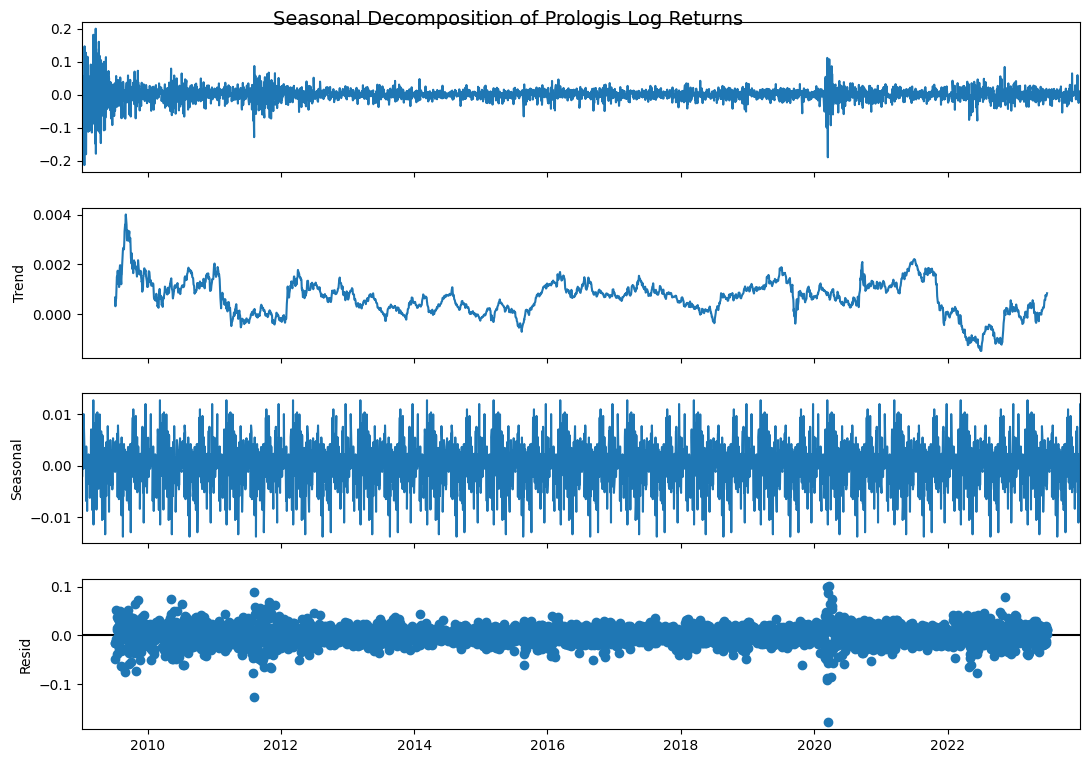

In [ ]:
# Ensure data is sorted and clean
data = data.sort_index()
data = data.dropna()

# Use Adjusted Close prices
prices = data['Close']

# Compute log returns
log_returns = np.log(prices / prices.shift(1))
log_returns = log_returns.dropna()

# Seasonal decomposition of log returns
decomposition = seasonal_decompose(
    log_returns,
    model='additive',
    period=252  #approximate number of trading days in a year
)

# Plot the decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition of Prologis Log Returns', fontsize=14)
plt.show()

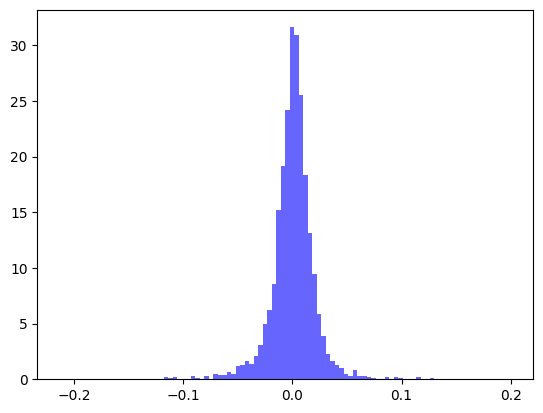

The skewness value for the log-returns data is: [-0.34312374]


In [ ]:
plt.hist(log_returns, bins=100, density=True, alpha=0.6, color='b')
plt.show()
print(f"The skewness value for the log-returns data is: {skew(log_returns)}")

Here, we compute the log-returns. We drop the first observation because the return calculation requires a lagged price. All subsequent analysis is performed on this log return series rather than prices.

It is not the easiest to fully see confirm that seasonality will not affect the results, so we will check this next by using the ADF test.

In [ ]:
# Perform Augmented Dickey-Fuller test on log returns
adf_result = adfuller(log_returns)

# Extract results
adf_statistic = adf_result[0]
p_value = adf_result[1]
used_lags = adf_result[2]
n_obs = adf_result[3]
critical_values = adf_result[4]

# Print ADF test results
print("Augmented Dickey-Fuller Test Results")
print("-----------------------------------")
print(f"ADF Statistic: {adf_statistic:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Number of Lags Used: {used_lags}")
print(f"Number of Observations: {n_obs}")
print("\nCritical Values:")
for key, value in critical_values.items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller Test Results
-----------------------------------
ADF Statistic: -12.5237
P-value: 0.000000
Number of Lags Used: 30
Number of Observations: 3742

Critical Values:
   1%: -3.4321
   5%: -2.8623
   10%: -2.5672


Since the p-value is 0, we confirm from the ADF test that our data has strong stationarity.

In [ ]:
# Square log returns to test for volatility clustering
squared_log_returns = log_returns**2

# Perform Ljung-Box test on squared log returns
lb_results = acorr_ljungbox(
    squared_log_returns,
    lags=[10, 15, 20, 100],
    return_df=True
)

# Display results
print("Ljung-Box Test Results on Squared Log Returns")
print("--------------------------------------------")
print(lb_results)

Ljung-Box Test Results on Squared Log Returns
--------------------------------------------
          lb_stat  lb_pvalue
10    4236.977818        0.0
15    5618.782033        0.0
20    6934.054731        0.0
100  13457.190845        0.0


From the Ljung-Box test, we see that there is clear evidence of volatility clustering, suggesting that the variance of returns is time-dependent.

/tmp/ipykernel_199/1439293925.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


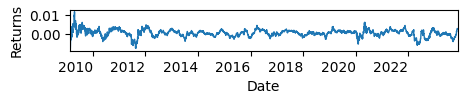

In [ ]:
fig, ax = plt.subplots(figsize=(5, 0.6))
log_returns.rolling(window=63, center=True).mean().plot(ax=ax, lw=1)
ax.set_ylabel("Returns")
ax.get_legend().remove()
plt.margins(x=0)
plt.xticks(rotation=0)
plt.tight_layout()

The above plot is generated to include a depiction of the log returns for Prologis in our presentation.

In [ ]:
!pip install arch

from arch import arch_model

# Scale returns (recommended for numerical stability)
returns = log_returns * 100

# Candidate GJR-GARCH (p, o, q) models
model_orders = [
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2)
]

results = {}

print("Estimating GJR-GARCH models with Student's t distribution\n")

for p, o, q in model_orders:
    model = arch_model(
        returns,
        mean="Constant",
        vol="GARCH",
        p=p,
        o=o,
        q=q,
        dist="StudentsT"   # <-- Standard Student's t distribution
    )

    fitted_model = model.fit(disp="off")

    results[(p, o, q)] = {
        "model": fitted_model,
        "bic": fitted_model.bic
    }

    print(f"GJR-GARCH({p},{o},{q}) | BIC: {fitted_model.bic:.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.4 MB/s eta 0:00:00
Estimating GJR-GARCH models with Student's t distribution

GJR-GARCH(1,1,1) | BIC: 14153.98
GJR-GARCH(2,1,1) | BIC: 14162.22
GJR-GARCH(1,1,2) | BIC: 14157.56
GJR-GARCH(2,1,2) | BIC: 14165.80


In [ ]:
# Find model with minimum BIC
best_order = min(results, key=lambda x: results[x]["bic"])
best_model = results[best_order]["model"]

print("\nBest Model Based on BIC")
print("-----------------------")
print(f"GJR-GARCH{best_order}")
print(f"BIC: {results[best_order]['bic']:.2f}")

# Full model summary
print(best_model.summary())


Best Model Based on BIC
-----------------------
GJR-GARCH(1, 1, 1)
BIC: 14153.98
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                          PLD   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -7052.28
Distribution:      Standardized Student's t   AIC:                           14116.6
Method:                  Maximum Likelihood   BIC:                           14154.0
                                              No. Observations:                 3773
Date:                      Tue, Mar 03 2026   Df Residuals:                     3772
Time:                              15:20:14   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
---

To model the conditional volatility of Prologis log returns, we use the GJR-GARCH framework, which extends the standard GARCH model by allowing volatility to react differently to positive and negative return shocks. This structure is well suited for financial time series, where downside movements often lead to larger increases in volatility. In estimation, the model is specified with a Student’s-t distribution rather than a normal distribution, allowing the model to capture the heavy-tailed behavior commonly observed in financial return data.

We estimate several GJR-GARCH specifications and select the final model using the Bayesian Information Criterion (BIC), which balances model fit with parsimony. Among the models considered, the GJR-GARCH(1,1,1) specification achieves the lowest BIC and is therefore selected as the preferred volatility model for this dataset.

The selected GJR-GARCH(1,1,1) model captures key features of the return series, including volatility clustering and asymmetric responses to shocks. The ARCH coefficient (α) measures the immediate impact of recent return shocks on volatility, while the GARCH coefficient (β) reflects persistence in conditional variance. The relatively large value of β indicates that volatility shocks decay slowly, meaning that periods of high volatility tend to be followed by continued elevated volatility. The asymmetry parameter (𝛾) is positive, indicating that negative return shocks increase future volatility more than positive shocks of the same magnitude. Additionally, the estimated degrees-of-freedom parameter of the Student’s-t distribution provides evidence of heavy tails, confirming that extreme return observations occur more frequently than would be predicted under a normal distribution.

From a forecasting perspective, the model produces time-varying volatility estimates that adjust to changing market conditions. The persistence implied by the volatility parameters suggests that volatility forecasts respond gradually to new information, while the leverage effect ensures that forecasts increase more strongly following negative return shocks. Combined with the heavy-tailed Student’s-t distribution, this leads to more realistic volatility forecasts during periods of market stress, making the model well suited for risk assessment and forward-looking volatility analysis.